# Discovering the Menu

*Learn what physics tengri offers, without writing a single model or fit.*

**What you'll do.** Walk through every discovery entrypoint — the `list_*()`,
`describe()`, `search()`, and `doctor()` functions — to learn what's available
in the registry. You'll filter tables by status or citation, probe the
metadata for a single model, cross-menu search for a concept, and check
whether your installation is healthy.

**Why this matters.** Before you build a model, you need to know what
physics is on offer. Tengri exposes this live — you discover as you go,
in the REPL or notebook, without leaving Python. Everything returns
real Python lists and dicts — no weird DSLs or CLIs.

**Runtime budget.** ~2 seconds total. Pure introspection, no compilation,
no fitting, no downloads. Filter tables, print metadata, search the
registry. Everything runs on the CPU regardless of GPU availability.

## 1. Global overview

Start with a bird's-eye view of everything in tengri.

In [1]:
import numpy as np

import tengri

# The one-liner summary: counts of every menu.
tengri.summary()


tengri — what's available:

     7  physics components           tengri.list_components()
    12  AGN models                   tengri.list_agn_models()
    21  dust attenuation laws        tengri.list_dust_laws()
     7  dust emission templates      tengri.list_dust_emission_models()
    34  SFH models                   tengri.list_sfh_models()
     4  nebular backends             tengri.list_nebular_backends()
   242  photometric filters          tengri.list_filters()
     8  plotting helpers             tengri.list_plots()
     6  primary inference methods    tengri.list_inference_methods(tier='primary')
    19  total inference methods      tengri.list_inference_methods()

  Look up any name:                          tengri.describe('skirtor')
  Curated cheatsheet for new users:          tengri.help()



**`tengri.summary()`** is what you run first after `import tengri`.
It prints live counts from every registry — add a new model
via `@register_agn_model` and this number updates automatically.

## 2. The full cheatsheet

**`tengri.help()`** is a 5-section narrative. Read it once to see the
entire surface area of the library.

In [2]:
tengri.help()


tengri — differentiable galaxy SED fitting in JAX

────────────────────────────────────────────────────────────────────
1.  See what's available
────────────────────────────────────────────────────────────────────
    tengri.summary()                      one-line counts of every menu
    tengri.list_agn_models()              12 AGN models
    tengri.list_dust_laws()               21 attenuation curves (UV/optical)
    tengri.list_dust_emission_models()    7 IR emission templates
    tengri.list_sfh_models()              34 SFH variants
    tengri.list_nebular_backends()        4 nebular backends
    tengri.list_inference_methods(tier="primary")  6 primary methods
    tengri.list_filters()                 242 filter curves
    tengri.describe("skirtor")            full metadata for any name
    tengri.search("torus")                cross-menu fuzzy search
    tengri.doctor()                       env / install / SSP health check
    tengri.help("dust")                   topical cheats

**`tengri.help("dust")`** narrows to one topic — dust attenuation +
emission in this case. Try other topics too:
`"agn"`, `"sfh"`, `"nebular"`, `"components"`, `"inference"`, `"filters"`,
`"plot"`, `"citations"`.

In [3]:
tengri.help("dust")


tengri.help('dust') — dust attenuation + emission: 28 available

name          kind              status        citation                                           short_doc                                               use                                       
────────────  ────────────────  ────────────  ─────────────────────────────────────────────────  ──────────────────────────────────────────────────────  ──────────────────────────────────────────
calzetti      dust_attenuation  production    Calzetti et al. 2000 (ApJ 533, 682)                Calzetti et al. starburst attenuation (R_V=4.05)        Parameters(..., dust_law="calzetti")      
cardelli      dust_attenuation  production    Cardelli et al. 1989 (ApJ 345, 245) MW extinction  Cardelli et al. MW extinction (parameterized R_V)       Parameters(..., dust_law="cardelli")      
conroy2010    dust_attenuation  production    Conroy et al. 2010 (ApJ 708, 58)                   Conroy+10 mixed MW + power-law (FSPS default)        

## 3. Listing menus

Each menu is a `_RegistryTable` — a real Python list that prints as a
nice table. You can filter it, iterate it, or slice it like any list.

### 3.1. Star formation histories

In [4]:
sfh_table = tengri.list_sfh_models()
print(f"Total SFH models: {len(sfh_table)}\n")
print(sfh_table)

Total SFH models: 34

name                       status      citation                                          short_doc                                          param_details                                                                   
─────────────────────────  ──────────  ────────────────────────────────────────────────  ─────────────────────────────────────────────────  ────────────────────────────────────────────────────────────────────────────────
buat08                     production  Buat et al. 2008                                  Velocity-parameterized SFH (Buat et al.)           [{'name': 'sfh_buat08_velocity_km_s', 'default': 'Uniform(80.0, 360.0)', 'des...
burst                      production                                                    Triweight burst kernel (Zacharegkas+2025)          [{'name': 'sfh_burst_log_fburst', 'default': 'Uniform(-3.0, -0.1)', 'descript...
const                      production                                                    Const

Narrow the table with `.filter()` — case-insensitive, chainable.

In [5]:
tengri.list_sfh_models().filter(citation__contains="Leja")

name,status,citation,short_doc,param_details
continuity,production,"Leja et al. 2019 (ApJ 876, 39)",Non-parametric piecewise continuity SFH (Leja+19),"[{'name': 'sfh_cont_log_total_mass', 'default': 'Uniform(8.0, 12.0)', 'description': 'log10 total stellar mass formed (Msun)'}, {'name': 'sfh_cont_ratio_0', 'default': 'Uniform(-1.0, 1.0)', 'description': 'log10 SFR ratio bin 0/1'}, {'name': 'sfh_cont_ratio_1', 'default': 'Uniform(-1.0, 1.0)', 'description': 'log10 SFR ratio bin 1/2'}, {'name': 'sfh_cont_ratio_2', 'default': 'Uniform(-1.0, 1.0)', 'description': 'log10 SFR ratio bin 2/3'}, {'name': 'sfh_cont_ratio_3', 'default': 'Uniform(-1.0, 1.0)', 'description': 'log10 SFR ratio bin 3/4'}, {'name': 'sfh_cont_ratio_4', 'default': 'Uniform(-1.0, 1.0)', 'description': 'log10 SFR ratio bin 4/5'}, {'name': 'sfh_cont_ratio_5', 'default': 'Uniform(-1.0, 1.0)', 'description': 'log10 SFR ratio bin 5/6'}]"
dirichlet,production,"Leja et al. 2017 (ApJ 837, 170)",Non-parametric Dirichlet SFH (Leja+17),"[{'name': 'sfh_dir_log_total_mass', 'default': 'Uniform(8.0, 12.0)', 'description': 'log10 total stellar mass formed (Msun)'}, {'name': 'sfh_dir_z_0', 'default': 'Uniform(0.01, 0.99)', 'description': 'Dirichlet stick-breaking variable 0'}, {'name': 'sfh_dir_z_1', 'default': 'Uniform(0.01, 0.99)', 'description': 'Dirichlet stick-breaking variable 1'}, {'name': 'sfh_dir_z_2', 'default': 'Uniform(0.01, 0.99)', 'description': 'Dirichlet stick-breaking variable 2'}, {'name': 'sfh_dir_z_3', 'default': 'Uniform(0.01, 0.99)', 'description': 'Dirichlet stick-breaking variable 3'}, {'name': 'sfh_dir_z_4', 'default': 'Uniform(0.01, 0.99)', 'description': 'Dirichlet stick-breaking variable 4'}, {'name': 'sfh_dir_z_5', 'default': 'Uniform(0.01, 0.99)', 'description': 'Dirichlet stick-breaking variable 5'}]"


### 3.2. Dust attenuation laws

Twenty-one curves for UV/optical absorption and scattering: Calzetti,
Cardelli, Charlot-Fall, Kriek & Conroy, Noll, Salim, SMC, LMC, and others.

In [6]:
tengri.list_dust_laws()

name,status,citation,short_doc
calzetti,production,"Calzetti et al. 2000 (ApJ 533, 682)",Calzetti et al. starburst attenuation (R_V=4.05)
cardelli,production,"Cardelli et al. 1989 (ApJ 345, 245) MW extinction",Cardelli et al. MW extinction (parameterized R_V)
conroy2010,production,"Conroy et al. 2010 (ApJ 708, 58)",Conroy+10 mixed MW + power-law (FSPS default)
d03_mwrv31,production,"Draine 2003 (ARA&A 41, 241)",Draine 2003 MW R_V=3.1 grain model attenuation
hd23_mwrv31,production,"Hensley & Draine 2023 (ApJ 948, 55)",Hensley & Draine 2023 astrodust+PAH grain model
kriek_conroy,production,"Kriek & Conroy 2013 (ApJL 775, L16)",Kriek & Conroy modified Calzetti + bump + slope
leitherer02,production,"Leitherer et al. 2002 (ApJS 140, 303)",Leitherer et al. UV starburst attenuation
li08,production,"Li et al. 2008 (ApJ 685, 1046)",Li et al. analytical flexible attenuation curve
lmc,production,"Pei 1992 (ApJ 395, 130) LMC","LMC extinction (Pei 1992, weak bump)"
narayanan_z,production,"Narayanan et al. 2018 (ApJ 869, 70)",Narayanan et al. z-dependent attenuation (SIMBA)


Filter by production status (exclude experimental models for conservative fits).

In [7]:
tengri.list_dust_laws().filter(status="production")

name,status,citation,short_doc
calzetti,production,"Calzetti et al. 2000 (ApJ 533, 682)",Calzetti et al. starburst attenuation (R_V=4.05)
cardelli,production,"Cardelli et al. 1989 (ApJ 345, 245) MW extinction",Cardelli et al. MW extinction (parameterized R_V)
conroy2010,production,"Conroy et al. 2010 (ApJ 708, 58)",Conroy+10 mixed MW + power-law (FSPS default)
d03_mwrv31,production,"Draine 2003 (ARA&A 41, 241)",Draine 2003 MW R_V=3.1 grain model attenuation
hd23_mwrv31,production,"Hensley & Draine 2023 (ApJ 948, 55)",Hensley & Draine 2023 astrodust+PAH grain model
kriek_conroy,production,"Kriek & Conroy 2013 (ApJL 775, L16)",Kriek & Conroy modified Calzetti + bump + slope
leitherer02,production,"Leitherer et al. 2002 (ApJS 140, 303)",Leitherer et al. UV starburst attenuation
li08,production,"Li et al. 2008 (ApJ 685, 1046)",Li et al. analytical flexible attenuation curve
lmc,production,"Pei 1992 (ApJ 395, 130) LMC","LMC extinction (Pei 1992, weak bump)"
narayanan_z,production,"Narayanan et al. 2018 (ApJ 869, 70)",Narayanan et al. z-dependent attenuation (SIMBA)


Filter by author — here Calzetti's law.

In [8]:
tengri.list_dust_laws().filter(citation__contains="Calzetti")

name,status,citation,short_doc
calzetti,production,"Calzetti et al. 2000 (ApJ 533, 682)",Calzetti et al. starburst attenuation (R_V=4.05)


### 3.3. Dust emission templates

Seven template families for IR re-radiation: DL07, DL14, Dale2014, THEMIS,
MBB, Astrodust, BOSA. Energy-balance fitting pairs these with attenuation.

In [9]:
tengri.list_dust_emission_models()

name,status,citation,short_doc
astrodust,experimental,"Hensley & Draine 2023 (ApJ 948, 55)",Astrodust + PAH unified grain model
bosa,experimental,Boquien et al. 2019 (CIGALE BOSA grids),BOSA dust SED templates
dale2014,production,"Dale et al. 2014 (ApJ 784, 83)",SFR-driven empirical IR template family (alpha_sf)
dl07,production,"Draine & Li 2007 (ApJ 657, 810)","Diffuse + PAH grain mixture, Umin/Umax/qpah"
dl14,production,"Draine et al. 2014 (ApJ 780, 172)",Updated DL with extended PAH and silicate features
mbb,production,"Casey 2012 (MNRAS 425, 3094)",Single-temperature modified blackbody (analytic)
themis,experimental,"Jones et al. 2017 (A&A 602, A46)",THEMIS amorphous-carbon grain model


### 3.4. Nebular backends

Four ways to compute emission lines: baked into the SSP grid (default),
or via neural emulator (CUE), cloud-physics grids (Cloudy, CB19).

In [10]:
tengri.list_nebular_backends()

name,status,citation,short_doc
baked_in,production,DSPS / FSPS SSP-internal,Emission baked into SSP grid; zero free params
cue,production,Li+2024 (CUE neural emulator),Neural-network Cloudy emulator
cloudy_grid,production,Byler+2017 grids,Trilinear interp on Cloudy grid
cb19,experimental,Charlot & Bruzual 2019,Precomputed CB19 nebular grid


### 3.5. AGN models

Twelve AGN configurations: Kubota & Done disc (full + simplified variants),
SKIRTOR torus geometry, multicolor continuum, ADAF accretion, plus QSOgen.

In [11]:
tengri.list_agn_models()

name,status,citation,short_doc,param_details
adaf,production,"Mahadevan 1997 (ApJ 477, 585)",ADAF + truncated disc + simple torus (low-luminosity),"[{'name': 'agn_log_lbol', 'default': 'Fixed(10.0)', 'description': 'AGN bolometric luminosity log10(L_bol / Lsun) — direct parametric mode'}, {'name': 'agn_frac', 'default': 'Fixed(0.0)', 'description': 'AGN luminosity fraction (L_AGN / L_stellar_bol)'}, {'name': 'agn_log_mbh', 'default': 'Fixed(7.0)', 'description': 'AGN black hole mass log10(M_BH/Msun)'}, {'name': 'agn_log_ledd', 'default': 'Fixed(-1.0)', 'description': 'AGN Eddington ratio log10(L/L_Edd)'}, {'name': 'agn_cos_inc', 'default': 'Fixed(0.5)', 'description': 'Cosine of inclination (0=edge-on, 1=face-on)'}, {'name': 'agn_torus_frac', 'default': 'Fixed(0.5)', 'description': 'AGN torus covering factor (fraction of L_bol re-emitted by torus)'}, {'name': 'agn_T_torus', 'default': 'Fixed(1000.0)', 'description': 'AGN torus temperature (K)'}]"
cat3d_wind,production,"Hönig & Kishimoto 2017 (ApJL 838, L20)",Power-law disc + CAT3D-Wind clumpy torus,"[{'name': 'agn_log_lbol', 'default': 'Fixed(10.0)', 'description': 'AGN bolometric luminosity log10(L_bol / Lsun) — direct parametric mode'}, {'name': 'agn_frac', 'default': 'Fixed(0.0)', 'description': 'AGN luminosity fraction (L_AGN / L_stellar_bol)'}, {'name': 'agn_cos_inc', 'default': 'Fixed(0.5)', 'description': 'Cosine of inclination (0=edge-on, 1=face-on)'}, {'name': 'agn_torus_frac', 'default': 'Fixed(0.5)', 'description': 'AGN torus covering factor (fraction of L_bol re-emitted by torus)'}]"
kubota_done,production,"Kubota & Done 2018 (MNRAS 480, 1247)",Shakura-Sunyaev disc + 2-T torus,"[{'name': 'agn_log_lbol', 'default': 'Fixed(10.0)', 'description': 'AGN bolometric luminosity log10(L_bol / Lsun) — direct parametric mode'}, {'name': 'agn_frac', 'default': 'Fixed(0.0)', 'description': 'AGN luminosity fraction (L_AGN / L_stellar_bol)'}, {'name': 'agn_log_mbh', 'default': 'Fixed(7.0)', 'description': 'AGN black hole mass log10(M_BH/Msun)'}, {'name': 'agn_log_ledd', 'default': 'Fixed(-1.0)', 'description': 'AGN Eddington ratio log10(L/L_Edd)'}, {'name': 'agn_a_spin', 'default': 'Fixed(0.0)', 'description': 'BH spin parameter a* in [0, 0.998) — controls ISCO and radiative efficiency'}, {'name': 'agn_cos_inc', 'default': 'Fixed(0.5)', 'description': 'Cosine of inclination (0=edge-on, 1=face-on)'}, {'name': 'agn_T_hot', 'default': 'Fixed(1200.0)', 'description': 'Two-temperature torus: hot dust component temperature [K]'}, {'name': 'agn_T_warm', 'default': 'Fixed(300.0)', 'description': 'Two-temperature torus: warm dust component temperature [K]'}, {'name': 'agn_frac_hot', 'default': 'Fixed(0.3)', 'description': 'Two-temperature torus: hot-to-warm dust luminosity fraction [0, 1]'}, {'name': 'agn_tau_torus', 'default': 'Fixed(5.0)', 'description': 'AGN torus optical depth at 9.7 um'}, {'name': 'agn_torus_frac', 'default': 'Fixed(0.5)', 'description': 'AGN torus covering factor (fraction of L_bol re-emitted by torus)'}]"
kubota_done_full,production,"Kubota & Done 2018 (MNRAS 480, 1247)",K&D 3-zone disc + 2-T torus + Comptonization,"[{'name': 'agn_log_lbol', 'default': 'Fixed(10.0)', 'description': 'AGN bolometric luminosity log10(L_bol / Lsun) — direct parametric mode'}, {'name': 'agn_frac', 'default': 'Fixed(0.0)', 'description': 'AGN luminosity fraction (L_AGN / L_stellar_bol)'}, {'name': 'agn_log_mbh', 'default': 'Fixed(7.0)', 'description': 'AGN black hole mass log10(M_BH/Msun)'}, {'name': 'agn_log_ledd', 'default': 'Fixed(-1.0)', 'description': 'AGN Eddington ratio log10(L/L_Edd)'}, {'name': 'agn_a_spin', 'default': 'Fixed(0.0)', 'description': 'BH spin parameter a* in [0, 0.998) — controls ISCO and radiative efficiency'}, {'name': 'agn_cos_inc', 'default': 'Fixed(0.5)', 'description': 'Cosine of inclination (0=edge-on, 1=face-on)'}, {'name': 'agn_f_hard', 'default': 'Fixed(0.02)', 'description': 'Coronal luminosity fraction (fraction of disc power to hot corona)'}, {'name': 

Filter to production-ready models.

In [12]:
tengri.list_agn_models().filter(status="production")

name,status,citation,short_doc,param_details
adaf,production,"Mahadevan 1997 (ApJ 477, 585)",ADAF + truncated disc + simple torus (low-luminosity),"[{'name': 'agn_log_lbol', 'default': 'Fixed(10.0)', 'description': 'AGN bolometric luminosity log10(L_bol / Lsun) — direct parametric mode'}, {'name': 'agn_frac', 'default': 'Fixed(0.0)', 'description': 'AGN luminosity fraction (L_AGN / L_stellar_bol)'}, {'name': 'agn_log_mbh', 'default': 'Fixed(7.0)', 'description': 'AGN black hole mass log10(M_BH/Msun)'}, {'name': 'agn_log_ledd', 'default': 'Fixed(-1.0)', 'description': 'AGN Eddington ratio log10(L/L_Edd)'}, {'name': 'agn_cos_inc', 'default': 'Fixed(0.5)', 'description': 'Cosine of inclination (0=edge-on, 1=face-on)'}, {'name': 'agn_torus_frac', 'default': 'Fixed(0.5)', 'description': 'AGN torus covering factor (fraction of L_bol re-emitted by torus)'}, {'name': 'agn_T_torus', 'default': 'Fixed(1000.0)', 'description': 'AGN torus temperature (K)'}]"
cat3d_wind,production,"Hönig & Kishimoto 2017 (ApJL 838, L20)",Power-law disc + CAT3D-Wind clumpy torus,"[{'name': 'agn_log_lbol', 'default': 'Fixed(10.0)', 'description': 'AGN bolometric luminosity log10(L_bol / Lsun) — direct parametric mode'}, {'name': 'agn_frac', 'default': 'Fixed(0.0)', 'description': 'AGN luminosity fraction (L_AGN / L_stellar_bol)'}, {'name': 'agn_cos_inc', 'default': 'Fixed(0.5)', 'description': 'Cosine of inclination (0=edge-on, 1=face-on)'}, {'name': 'agn_torus_frac', 'default': 'Fixed(0.5)', 'description': 'AGN torus covering factor (fraction of L_bol re-emitted by torus)'}]"
kubota_done,production,"Kubota & Done 2018 (MNRAS 480, 1247)",Shakura-Sunyaev disc + 2-T torus,"[{'name': 'agn_log_lbol', 'default': 'Fixed(10.0)', 'description': 'AGN bolometric luminosity log10(L_bol / Lsun) — direct parametric mode'}, {'name': 'agn_frac', 'default': 'Fixed(0.0)', 'description': 'AGN luminosity fraction (L_AGN / L_stellar_bol)'}, {'name': 'agn_log_mbh', 'default': 'Fixed(7.0)', 'description': 'AGN black hole mass log10(M_BH/Msun)'}, {'name': 'agn_log_ledd', 'default': 'Fixed(-1.0)', 'description': 'AGN Eddington ratio log10(L/L_Edd)'}, {'name': 'agn_a_spin', 'default': 'Fixed(0.0)', 'description': 'BH spin parameter a* in [0, 0.998) — controls ISCO and radiative efficiency'}, {'name': 'agn_cos_inc', 'default': 'Fixed(0.5)', 'description': 'Cosine of inclination (0=edge-on, 1=face-on)'}, {'name': 'agn_T_hot', 'default': 'Fixed(1200.0)', 'description': 'Two-temperature torus: hot dust component temperature [K]'}, {'name': 'agn_T_warm', 'default': 'Fixed(300.0)', 'description': 'Two-temperature torus: warm dust component temperature [K]'}, {'name': 'agn_frac_hot', 'default': 'Fixed(0.3)', 'description': 'Two-temperature torus: hot-to-warm dust luminosity fraction [0, 1]'}, {'name': 'agn_tau_torus', 'default': 'Fixed(5.0)', 'description': 'AGN torus optical depth at 9.7 um'}, {'name': 'agn_torus_frac', 'default': 'Fixed(0.5)', 'description': 'AGN torus covering factor (fraction of L_bol re-emitted by torus)'}]"
kubota_done_full,production,"Kubota & Done 2018 (MNRAS 480, 1247)",K&D 3-zone disc + 2-T torus + Comptonization,"[{'name': 'agn_log_lbol', 'default': 'Fixed(10.0)', 'description': 'AGN bolometric luminosity log10(L_bol / Lsun) — direct parametric mode'}, {'name': 'agn_frac', 'default': 'Fixed(0.0)', 'description': 'AGN luminosity fraction (L_AGN / L_stellar_bol)'}, {'name': 'agn_log_mbh', 'default': 'Fixed(7.0)', 'description': 'AGN black hole mass log10(M_BH/Msun)'}, {'name': 'agn_log_ledd', 'default': 'Fixed(-1.0)', 'description': 'AGN Eddington ratio log10(L/L_Edd)'}, {'name': 'agn_a_spin', 'default': 'Fixed(0.0)', 'description': 'BH spin parameter a* in [0, 0.998) — controls ISCO and radiative efficiency'}, {'name': 'agn_cos_inc', 'default': 'Fixed(0.5)', 'description': 'Cosine of inclination (0=edge-on, 1=face-on)'}, {'name': 'agn_f_hard', 'default': 'Fixed(0.02)', 'description': 'Coronal luminosity fraction (fraction of disc power to hot corona)'}, {'name': 

### 3.6. Inference methods

Primary methods for new users: HMC/NUTS (exact posterior), MAP (point
estimate), geoVI (fast approximation). Experimental: raytrace, NSS.

In [13]:
tengri.list_inference_methods(tier="primary")

name,tier,short_doc
map,primary,Adam MAP optimization
mcmc,primary,"Auto MCMC: NUTS for low-D, raytrace for high-D"
mcmc_nuts,primary,No-U-Turn Sampler
mcmc_raytrace,primary,Ray-tracing ensemble sampler (high-D)
vi,primary,NIFTy geoVI variational inference
vi_nonlinear_fast,primary,NIFTy geoVI without Python logging


Show all methods, including experimental.

In [14]:
tengri.list_inference_methods()

name,tier,short_doc
map,primary,Adam MAP optimization
mcmc,primary,"Auto MCMC: NUTS for low-D, raytrace for high-D"
mcmc_nuts,primary,No-U-Turn Sampler
mcmc_raytrace,primary,Ray-tracing ensemble sampler (high-D)
vi,primary,NIFTy geoVI variational inference
vi_nonlinear_fast,primary,NIFTy geoVI without Python logging
laplace,experimental,Laplace approximation
mcmc_adjusted_mclmc,experimental,Adjusted microcanonical Langevin sampler
mcmc_dynamic_hmc,experimental,Dynamic HMC with adaptive step size
mcmc_ess,experimental,Elliptical slice sampling


### 3.7. Physics components

The core SED pipeline: stellar (SFH + SSP), dust (attenuation + emission),
AGN, nebular (emission lines), radio, IGM, X-ray.

In [15]:
tengri.list_components()

name,status,short_doc
stellar,production,"SSP integration over SFH (DSPS), metallicity history, mass remaining"
dust,production,Two-component attenuation (BC + diffuse) — 21 laws available
agn,production,Disc + torus + polar dust + BLR/NLR — 12 models available
nebular,production,Emission lines + continuum — BakedIn / CUE / CloudyGrid / CB19
radio,production,SF synchrotron + AGN jets + free-free continuum
igm,production,IGM transmission (Inoue+2014) + DLA absorption
xray,production,X-ray binaries + AGN corona


### 3.8. Plotting helpers

Matplotlib wrappers for common figures: SED fits, SFH curves, corner plots,
corner comparisons, spectrum fits, diagnostics tables.

In [16]:
tengri.list_plots()

name,status,short_doc
plot_sed_fit,production,Plot observed photometry/spectrum + posterior SED + uncertainty band
plot_spectrum_fit,production,Plot spectrum + posterior model with calibration polynomial
plot_sfh,production,Plot single SFH(t) curve from a Parameters / Posterior
plot_sfh_comparison,production,Overlay multiple SFH(t) curves (e.g. truth vs posterior)
plot_corner_comparison,production,Two-posterior corner plot (e.g. with truth)
safe_corner,production,Corner plot wrapper that handles fixed parameters gracefully
setup_style,production,"Apply tengri matplotlib style (serif, tight, 150 dpi)"
diagnostics_table,production,ESS / R-hat / divergences table for sampling diagnostics


### 3.9. Photometric filters

242+ filter curves from the SVO Filter Profile Service: SDSS, GALEX, 2MASS,
WISE, HST, Euclid, JWST, and more.

In [17]:
n_filters = len(tengri.list_filters())
print(f"Total filters: {n_filters}\n")

Total filters: 242



Filter by survey using astronomer-friendly aliases.

In [18]:
tengri.list_filters(survey="SDSS")

name,survey,instrument,band
SLOAN_SDSS_g,SLOAN,SDSS,g
SLOAN_SDSS_i,SLOAN,SDSS,i
SLOAN_SDSS_r,SLOAN,SDSS,r
SLOAN_SDSS_u,SLOAN,SDSS,u
SLOAN_SDSS_z,SLOAN,SDSS,z


**Smart survey aliases.** `survey="SDSS"` matches `SLOAN_SDSS_*` rows
even though "SDSS" is the *instrument* in SVO's filename schema, not the
survey. Works for `"DES"`, `"VISTA"`, `"HSC"`, `"UKIDSS"`, `"PS1"` too.

In [19]:
tengri.list_filters(survey="GALEX")

name,survey,instrument,band
GALEX_GALEX_FUV,GALEX,GALEX,FUV
GALEX_GALEX_NUV,GALEX,GALEX,NUV


#### Chaining filters — a real example

Chain `.filter()` calls to narrow down. Here we find JWST NIRCam filters
with "F150" in the band name.

In [20]:
jwst_nircam_f150 = (
    tengri.list_filters()
    .filter(survey="JWST")
    .filter(instrument="NIRCam", band__contains="F150")
)
print(f"JWST NIRCam F150 filters: {len(jwst_nircam_f150)}\n")
print(jwst_nircam_f150)

JWST NIRCam F150 filters: 2

name                survey  instrument  band  
──────────────────  ──────  ──────────  ──────
JWST_NIRCam_F150W   JWST    NIRCam      F150W 
JWST_NIRCam_F150W2  JWST    NIRCam      F150W2
[2 results — filter]
  Use:  tengri.describe('JWST_NIRCam_F150W')  →  Photometry.from_names(["JWST_NIRCam_F150W"])


The `.names()` method extracts just the string list — feeds directly
into `Photometry.from_names()` for zero-friction filter discovery.

In [21]:
filter_names = jwst_nircam_f150.names()
print(f"Filter names for Photometry():\n{filter_names}")

Filter names for Photometry():
['JWST_NIRCam_F150W', 'JWST_NIRCam_F150W2']


## 4. API discovery surface

Tengri exposes more discovery helpers beyond the menus above.

### 4.1. Filter suggestion by redshift

In [22]:
# Suggest a bandset for a low-redshift galaxy (z=0.05) and a high-z target (z=2.5).
low_z_filters = tengri.filters.suggest(redshift=0.05, coverage="visible_to_nir")
print(f"Suggested filters for z=0.05:\n  {low_z_filters}\n")

high_z_filters = tengri.filters.suggest(redshift=2.5, coverage="visible_to_nir")
print(f"Suggested filters for z=2.5:\n  {high_z_filters}\n")

Suggested filters for z=0.05:
  ['megacam_u', 'lsst_u', 'megacam_u2', 'suprime_ib427', 'hst_f435w', 'xmm_b', 'uvot_b', 'johnson_b', 'suprime_b', 'suprime_ib464', 'sdss_g', 'des_g', 'suprime_g', 'megacam_g', 'lsst_g', 'hsc_g', 'suprime_ib484', 'megacam_g2', 'ps1_g', 'suprime_ib505', 'suprime_ib527', 'xmm_v', 'uvot_v', 'suprime_v', 'johnson_v', 'suprime_ib574', 'hst_f606w', 'sdss_r', 'ps1_r', 'hsc_r', 'lsst_r', 'suprime_ib624', 'megacam_r2', 'suprime_r', 'roman_f062', 'megacam_r', 'des_r', 'cousins_r', 'suprime_rc', 'suprime_na656', 'suprime_ib679', 'johnson_r', 'jwst_f070w', 'nircam25_f070w', 'suprime_ib709', 'suprime_nb711', 'euclid_vis', 'suprime_ib738', 'sdss_i', 'lsst_i', 'ps1_i', 'megacam_i3', 'suprime_i', 'suprime_ib767', 'megacam_i2', 'megacam_i', 'hst_f775w', 'hsc_i', 'des_i', 'cousins_i', 'suprime_ic', 'hst_f814w', 'suprime_nb816', 'suprime_ib827', 'ps1_z', 'lsst_z', 'roman_f087', 'johnson_i', 'vista_z', 'megacam_z2', 'ukidss_z', 'hsc_z', 'sdss_z', 'megacam_z', 'niriss_f090w', 

### 4.2. Filter properties and metadata

In [23]:
# Inspect a single filter in detail.
info = tengri.filters.filter_info("jwst_f200w")
print(f"Filter info for {info['name']}:")
print(f"  Facility: {info['facility']}")
print(f"  λ_eff: {info['lambda_eff_str']}")
print(f"  FWHM: {info['fwhm_str']}\n")

Filter info for jwst_f200w:
  Facility: JWST/NIRCam
  λ_eff: 1.99 μm
  FWHM: 4700 Å



Compute effective wavelength and FWHM for any filter.

In [24]:
# Load a few filters and compute their properties
test_filters = ["sdss_u", "sdss_g", "2mass_j"]
for fname in test_filters:
    fc = tengri.filters.load_filter(fname)
    wave_np, trans_np = (np.asarray(fc.wave), np.asarray(fc.trans))
    lam_eff = tengri.filters.compute_effective_wavelength(wave_np, trans_np)
    fwhm = tengri.filters.compute_fwhm(wave_np, trans_np)
    print(f"{fname:15s}  λ_eff={lam_eff:8.1f} Å  FWHM={fwhm:7.1f} Å")

sdss_u           λ_eff=  3561.8 Å  FWHM=  575.0 Å
sdss_g           λ_eff=  4718.9 Å  FWHM= 1250.0 Å
2mass_j          λ_eff= 12410.5 Å  FWHM= 2140.0 Å


### 4.3. Introspection API

In [25]:
# List available example scripts
try:
    tengri.examples()
except NotImplementedError:
    print("❋ api preview — examples() not yet implemented\n")


tengri runnable example scripts (133 total):

  examples/advanced/plot_fisher_degeneracy.py                   Age-Dust-Metallicity Degeneracy: Fisher Analysis
  examples/advanced/plot_gradient_sensitivity.py                Gradient Sensitivity Heatmap
  examples/advanced/plot_hierarchical.py                        Hierarchical PSD Inference
  examples/advanced/plot_joint_fit.py                           Joint Photometry + Spectroscopy Fit
  examples/advanced/plot_orchestrator_demo.py                   Component orchestrator end-to-end
  examples/advanced/plot_radio_xray.py                          Panchromatic SED: UV to Radio
  examples/agn/plot_agn_alpha_ox_lbol_2d.py                     X-ray Corona: Spectral Index vs Bolometric Luminosity 2D Sweep
  examples/agn/plot_agn_cos_inc_sweep.py                        SKIRTOR Torus: Viewing Angle Sweep
  examples/agn/plot_agn_hierarchy.py                            AGN SEDModel Hierarchy
  examples/agn/plot_agn_log_lbol_sweep.py          

Explain the role of major classes.

In [26]:
# Show architectural role of SEDModel and Posterior
try:
    tengri.explain(tengri.SEDModel)
except NotImplementedError:
    print("❋ api preview — explain() not yet implemented\n")


SEDModel
────────
FORWARD MODEL  (layer 2)
Wires Parameters + SSP + Observation into one JIT-compiled function:
  predict_photometry(params) → flux array.
  Tutorial:     tengri.tutorial('key_classes')



Print the fun easter egg.

In [27]:
tengri.print_logo()

                            ████████
                        ████████████████
                     ██████          ██████
                 ███████                ███████
              ██████                        ██████
           ██████                              ██████
        ██████         █████████████████          ██████
     ██████        ██████            ███████         ██████
  █████         █████                     █████          █████
 ████         ████        ██████████         ████          ████
████        ████     ████████   ████████       ████         ████
███        ███    ████       ████     █████      ████        ███
███       ███  ████     ██████████████   ████      ███       ███
███      ███ ███     █████         █████   ███      ███      ███
███     ███ ██     ████    ████████   ████  ███      ███     ███
███     ██ ██     ███   ██████  █████  ████  ███      ███    ███
███    ██ █      ███  ████  ██████ ███  ███  ███      ███    ███
███    ████     ███  ███  

### 4.4. Parameter suggestion

In [28]:
# Ask tengri to suggest default parameters for a given configuration
try:
    suggested = tengri.suggest_parameters(
        mean_sfh_type="dpl",
        dust_law_bc="calzetti",
        dust_emission="dale2014",
    )
    print("Suggested parameter set:")
    print(suggested)
except (NotImplementedError, TypeError):
    print("❋ api preview — suggest_parameters() under development\n")


Parameters configuration: mean_sfh_type='dpl', dust_emission='dale2014'
  → 30 parameters.  Pass any subset as kwargs to tengri.Parameters().

Suggested parameter set:
name                  default             description                                                                     
────────────────────  ──────────────────  ────────────────────────────────────────────────────────────────────────────────
dust_Rv               Fixed(3.1)          Total-to-selective extinction R_V (Cardelli)                                    
dust_T                Fixed(35.0)         Dust temperature (K) for greybody/Casey emission                                
dust_T_cold           Fixed(20.0)         Cold ISM grain temperature (K) — used by the two-temperature emission model (...
dust_T_warm           Fixed(45.0)         Warm birth-cloud grain temperature (K) — used by two-temp emission model (30-...
dust_alpha_dale       Fixed(2.0)          Dale et al. 2014 alpha parameter (0.0625-4.0)      

### 4.5. Bibliography registry

In [29]:
# Cite a single author/model by key
try:
    tengri.cite("calzetti")
except (KeyError, TypeError):
    print("❋ No direct cite('calzetti') in this version; see cite_components()\n")

❋ No direct cite('calzetti') in this version; see cite_components()



### 4.6. List all registries at once

In [30]:
all_tables = tengri.list_all()
total = sum(len(table) for table in all_tables.values())
print(f"Total catalog size: {total} entries")
for kind, table in all_tables.items():
    print(f"  {kind:25s}: {len(table):3d}")
    if len(table) > 0:
        print(f"    {table[0] if isinstance(table[0], dict) else table[0].name}")
    print()

Total catalog size: 354 entries
  components               :   7
    {'name': 'stellar', 'kind': 'component', 'status': 'production', 'module': 'tengri.components.stellar.component', 'short_doc': 'SSP integration over SFH (DSPS), metallicity history, mass remaining', 'use': 'tengri.stellar  (see list_stellar_models / list_stellar_laws for alternatives)'}

  inference_methods        :  19
    {'name': 'map', 'kind': 'inference_method', 'tier': 'primary', 'short_doc': 'Adam MAP optimization', 'requires': ['optax'], 'use': 'fitter.run("map")'}

  agn_models               :  12
    {'name': 'adaf', 'kind': 'agn_model', 'status': 'production', 'citation': 'Mahadevan 1997 (ApJ 477, 585)', 'short_doc': 'ADAF + truncated disc + simple torus (low-luminosity)', 'use': 'Parameters(..., agn_model="adaf")', 'params': ['agn_log_lbol', 'agn_frac', 'agn_log_mbh', 'agn_log_ledd', 'agn_r_tr', 'agn_adaf_beta', 'agn_adaf_delta', 'agn_cos_inc', 'agn_torus_frac', 'agn_T_torus', 'agn_ebv_disc'], 'param_detai

### 4.7. Filter operators reference

The `.filter()` method supports several operators for fine-grained queries.

In [31]:
# Example: exact match
exact = tengri.list_filters().filter(instrument="MIRI").names()[:3]
print(f"Exact match (instrument='MIRI'): {exact}\n")

# Example: contains
contains = (
    tengri.list_filters()
    .filter(band__contains="F150")
    .names()[:3]
)
print(f"Contains (band__contains='F150'): {contains}\n")

# Example: startswith
startswith = (
    tengri.list_filters()
    .filter(survey__startswith="JWST")
    .names()[:3]
)
print(f"Startswith (survey__startswith='JWST'): {startswith}\n")

# Example: in tuple (multiple values)
in_tuple = (
    tengri.list_filters()
    .filter(instrument__in=("NIRCam", "MIRI"))
    .names()[:3]
)
print(f"In tuple (instrument__in=...): {in_tuple}\n")

Exact match (instrument='MIRI'): ['JWST_MIRI_F1000W', 'JWST_MIRI_F1065C', 'JWST_MIRI_F1130W']

Contains (band__contains='F150'): ['JWST_MIRI_F1500W', 'JWST_NIRCam2025_F150W', 'JWST_NIRCam2025_F150W2']

Startswith (survey__startswith='JWST'): ['JWST_MIRI_F1000W', 'JWST_MIRI_F1065C', 'JWST_MIRI_F1130W']

In tuple (instrument__in=...): ['JWST_MIRI_F1000W', 'JWST_MIRI_F1065C', 'JWST_MIRI_F1130W']



## 5. Single-entry lookup

Use **`describe()`** to get full metadata for any name — model, method,
component, or filter.

In [32]:
tengri.describe("calzetti")

name,calzetti
kind,dust_attenuation
status,production
citation,"Calzetti et al. 2000 (ApJ 533, 682)"
short_doc,Calzetti et al. starburst attenuation (R_V=4.05)
use,"Parameters(..., dust_law=""calzetti"")"


Describe an AGN model.

In [33]:
tengri.describe("skirtor")

name,skirtor
kind,agn_model
status,production
citation,"Stalevski et al. 2012 (MNRAS 420, 2756); Stalevski et al. 2016 (MNRAS 458, 2288)"
short_doc,Power-law disc + SKIRTOR clumpy torus
use,"Parameters(..., agn_model=""skirtor"")"
params,agn_log_lbolagn_fracagn_tau_skirtoragn_p_skirtoragn_q_skirtoragn_oa_skirtoragn_cos_incagn_torus_fracagn_ebv_disc
param_details,"[{'name': 'agn_log_lbol', 'default': 'Fixed(10.0)', 'description': 'AGN bolometric luminosity log10(L_bol / Lsun) — direct parametric mode'}, {'name': 'agn_frac', 'default': 'Fixed(0.0)', 'description': 'AGN luminosity fraction (L_AGN / L_stellar_bol)'}, {'name': 'agn_tau_skirtor', 'default': 'Fixed(7.0)', 'description': 'SKIRTOR 9.7 um optical depth (3-11)'}, {'name': 'agn_p_skirtor', 'default': 'Fixed(1.0)', 'description': 'SKIRTOR radial density power-law gradient (0-1.5)'}, {'name': 'agn_q_skirtor', 'default': 'Fixed(1.0)', 'description': 'SKIRTOR polar density power-law gradient (0-1.5)'}, {'name': 'agn_oa_skirtor', 'default': 'Fixed(40.0)', 'description': 'SKIRTOR torus half-opening angle [degrees] (20-60)'}, {'name': 'agn_cos_inc', 'default': 'Fixed(0.5)', 'description': 'Cosine of inclination (0=edge-on, 1=face-on)'}, {'name': 'agn_torus_frac', 'default': 'Fixed(0.5)', 'description': 'AGN torus covering factor (fraction of L_bol re-emitted by torus)'}]"


Describe an inference method.

In [34]:
tengri.describe("mcmc_nuts")

name,mcmc_nuts
kind,inference_method
tier,primary
short_doc,No-U-Turn Sampler
requires,blackjax
use,"fitter.run(""mcmc_nuts"")"


Describe a dust emission template.

In [35]:
tengri.describe("dale2014")

name,dale2014
status,production
citation,"Dale et al. 2014 (ApJ 784, 83)"
short_doc,SFR-driven empirical IR template family (alpha_sf)
use,"Parameters(..., dust_emission=""dale2014"")"
kind,dust_emission


## 5. Cross-menu search

**`search()`** walks every registry and returns every entry whose name,
short_doc, citation, or status (case-insensitive) contains your query.
Hits from different menus get a `kind` column so you can tell them apart.

In [36]:
tengri.search("torus")

name,kind,status,short_doc,use
agn,component,production,Disc + torus + polar dust + BLR/NLR — 12 models available,tengri.agn (see list_agn_models / list_agn_laws for alternatives)
adaf,agn_model,production,ADAF + truncated disc + simple torus (low-luminosity),"Parameters(..., agn_model=""adaf"")"
cat3d_wind,agn_model,production,Power-law disc + CAT3D-Wind clumpy torus,"Parameters(..., agn_model=""cat3d_wind"")"
kubota_done,agn_model,production,Shakura-Sunyaev disc + 2-T torus,"Parameters(..., agn_model=""kubota_done"")"
kubota_done_full,agn_model,production,K&D 3-zone disc + 2-T torus + Comptonization,"Parameters(..., agn_model=""kubota_done_full"")"
multicolor_agn,agn_model,production,Shakura-Sunyaev disc + 2-T torus,"Parameters(..., agn_model=""multicolor_agn"")"
relagn,agn_model,production,RELAGN relativistic disc + 2-T torus,"Parameters(..., agn_model=""relagn"")"
silva04,agn_model,production,Power-law disc + Silva+04 smooth torus,"Parameters(..., agn_model=""silva04"")"
simple,agn_model,demo,Toy 3-zone disc + single-T torus,"Parameters(..., agn_model=""simple"")"
skirtor,agn_model,production,Power-law disc + SKIRTOR clumpy torus,"Parameters(..., agn_model=""skirtor"")"


Search for "dirichlet" SFH.

In [37]:
tengri.search("dirichlet")

name,status,citation,short_doc,param_details
dirichlet,production,"Leja et al. 2017 (ApJ 837, 170)",Non-parametric Dirichlet SFH (Leja+17),"[{'name': 'sfh_dir_log_total_mass', 'default': 'Uniform(8.0, 12.0)', 'description': 'log10 total stellar mass formed (Msun)'}, {'name': 'sfh_dir_z_0', 'default': 'Uniform(0.01, 0.99)', 'description': 'Dirichlet stick-breaking variable 0'}, {'name': 'sfh_dir_z_1', 'default': 'Uniform(0.01, 0.99)', 'description': 'Dirichlet stick-breaking variable 1'}, {'name': 'sfh_dir_z_2', 'default': 'Uniform(0.01, 0.99)', 'description': 'Dirichlet stick-breaking variable 2'}, {'name': 'sfh_dir_z_3', 'default': 'Uniform(0.01, 0.99)', 'description': 'Dirichlet stick-breaking variable 3'}, {'name': 'sfh_dir_z_4', 'default': 'Uniform(0.01, 0.99)', 'description': 'Dirichlet stick-breaking variable 4'}, {'name': 'sfh_dir_z_5', 'default': 'Uniform(0.01, 0.99)', 'description': 'Dirichlet stick-breaking variable 5'}]"


Search by author — everything Leja-cited.

In [38]:
tengri.search("Leja")

name,status,citation,short_doc,param_details
continuity,production,"Leja et al. 2019 (ApJ 876, 39)",Non-parametric piecewise continuity SFH (Leja+19),"[{'name': 'sfh_cont_log_total_mass', 'default': 'Uniform(8.0, 12.0)', 'description': 'log10 total stellar mass formed (Msun)'}, {'name': 'sfh_cont_ratio_0', 'default': 'Uniform(-1.0, 1.0)', 'description': 'log10 SFR ratio bin 0/1'}, {'name': 'sfh_cont_ratio_1', 'default': 'Uniform(-1.0, 1.0)', 'description': 'log10 SFR ratio bin 1/2'}, {'name': 'sfh_cont_ratio_2', 'default': 'Uniform(-1.0, 1.0)', 'description': 'log10 SFR ratio bin 2/3'}, {'name': 'sfh_cont_ratio_3', 'default': 'Uniform(-1.0, 1.0)', 'description': 'log10 SFR ratio bin 3/4'}, {'name': 'sfh_cont_ratio_4', 'default': 'Uniform(-1.0, 1.0)', 'description': 'log10 SFR ratio bin 4/5'}, {'name': 'sfh_cont_ratio_5', 'default': 'Uniform(-1.0, 1.0)', 'description': 'log10 SFR ratio bin 5/6'}]"
dirichlet,production,"Leja et al. 2017 (ApJ 837, 170)",Non-parametric Dirichlet SFH (Leja+17),"[{'name': 'sfh_dir_log_total_mass', 'default': 'Uniform(8.0, 12.0)', 'description': 'log10 total stellar mass formed (Msun)'}, {'name': 'sfh_dir_z_0', 'default': 'Uniform(0.01, 0.99)', 'description': 'Dirichlet stick-breaking variable 0'}, {'name': 'sfh_dir_z_1', 'default': 'Uniform(0.01, 0.99)', 'description': 'Dirichlet stick-breaking variable 1'}, {'name': 'sfh_dir_z_2', 'default': 'Uniform(0.01, 0.99)', 'description': 'Dirichlet stick-breaking variable 2'}, {'name': 'sfh_dir_z_3', 'default': 'Uniform(0.01, 0.99)', 'description': 'Dirichlet stick-breaking variable 3'}, {'name': 'sfh_dir_z_4', 'default': 'Uniform(0.01, 0.99)', 'description': 'Dirichlet stick-breaking variable 4'}, {'name': 'sfh_dir_z_5', 'default': 'Uniform(0.01, 0.99)', 'description': 'Dirichlet stick-breaking variable 5'}]"


## 9. Environment health

**`doctor()`** checks whether your install is healthy: Python version,
JAX configuration, SSP data files, GPU availability.

In [39]:
tengri.doctor()

                            ████████
                        ████████████████
                     ██████          ██████
                 ███████                ███████
              ██████                        ██████
           ██████                              ██████
        ██████         █████████████████          ██████
     ██████        ██████            ███████         ██████
  █████         █████                     █████          █████
 ████         ████        ██████████         ████          ████
████        ████     ████████   ████████       ████         ████
███        ███    ████       ████     █████      ████        ███
███       ███  ████     ██████████████   ████      ███       ███
███      ███ ███     █████         █████   ███      ███      ███
███     ███ ██     ████    ████████   ████  ███      ███     ███
███     ██ ██     ███   ██████  █████  ████  ███      ███    ███
███    ██ █      ███  ████  ██████ ███  ███  ███      ███    ███
███    ████     ███  ███  

'                            ████████\n                        ████████████████\n                     ██████          ██████\n                 ███████                ███████\n              ██████                        ██████\n           ██████                              ██████\n        ██████         █████████████████          ██████\n     ██████        ██████            ███████         ██████\n  █████         █████                     █████          █████\n ████         ████        ██████████         ████          ████\n████        ████     ████████   ████████       ████         ████\n███        ███    ████       ████     █████      ████        ███\n███       ███  ████     ██████████████   ████      ███       ███\n███      ███ ███     █████         █████   ███      ███      ███\n███     ███ ██     ████    ████████   ████  ███      ███     ███\n███     ██ ██     ███   ██████  █████  ████  ███      ███    ███\n███    ██ █      ███  ████  ██████ ███  ███  ███      ███    ███\n███    █

## 8. Hero figure: Photometric filter coverage

Build a multi-wavelength filter set and visualize their transmission curves.
Color by effective wavelength to reveal the spectral coverage, and annotate
the Balmer break at z=0.1.

Loading filters: ['sdss_u', 'sdss_g', 'sdss_r', 'sdss_i', 'sdss_z', '2mass_j', '2mass_h', '2mass_ks']

Loaded 8 filters




✓ Saved hero figure to figures/03_filter_coverage.png


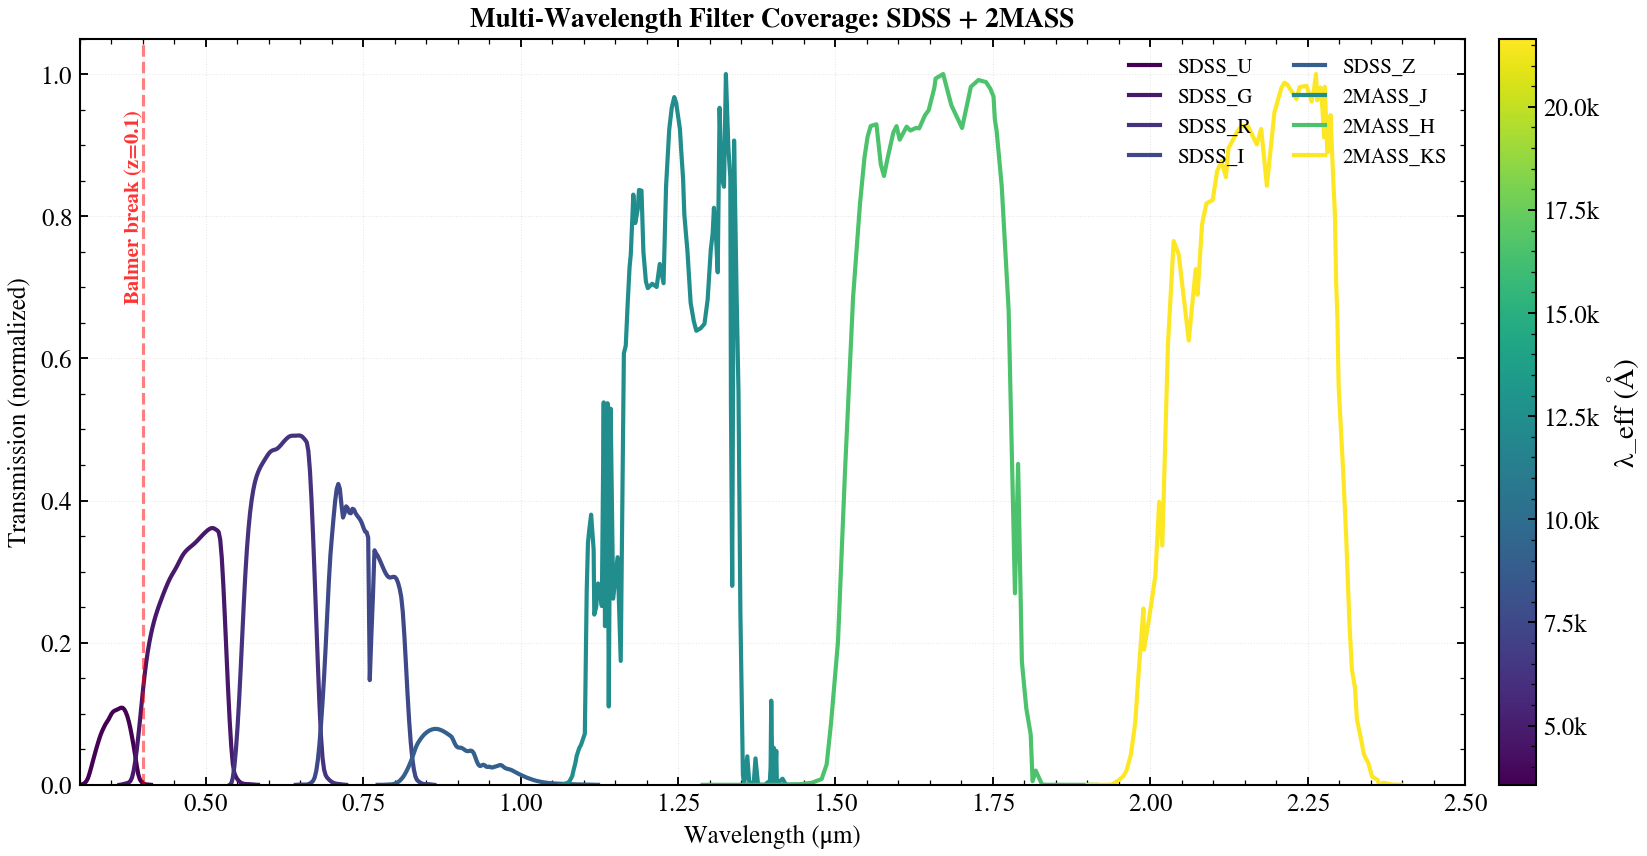

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# Set publication-style defaults
tengri.plot.setup_style()

# 1. Discover filters via the chained API — use available registry names
# Build a representative set: SDSS optical + 2MASS near-IR
sdss_names = ["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]
ir_names = ["2mass_j", "2mass_h", "2mass_ks"]
all_filter_names = sdss_names + ir_names
print(f"Loading filters: {all_filter_names}\n")

# 2. Load each filter and collect metadata
filters_data = []
for name in all_filter_names:
    try:
        fc = tengri.filters.load_filter(name)
        wave_np, trans_np = np.asarray(fc.wave), np.asarray(fc.trans)
        lam_eff = tengri.filters.compute_effective_wavelength(wave_np, trans_np)
        filters_data.append({
            'name': name,
            'wave': wave_np,
            'trans': trans_np,
            'lam_eff': lam_eff
        })
    except KeyError as e:
        print(f"⚠ Skipping {name}: {e}")

print(f"Loaded {len(filters_data)} filters\n")

# 3. Create the figure with a shared wavelength axis
fig, ax = plt.subplots(figsize=(12, 6))

# Color map: effective wavelength → perceptual color
lam_effs = np.array([f['lam_eff'] for f in filters_data])
norm = Normalize(vmin=lam_effs.min(), vmax=lam_effs.max())
cmap = plt.get_cmap("viridis")

# Plot each filter's transmission curve
for fdata in filters_data:
    color = cmap(norm(fdata['lam_eff']))
    ax.plot(fdata['wave'] / 1e4, fdata['trans'], linewidth=2.0, color=color,
            label=fdata['name'].upper())

# 4. Annotate the Balmer break for a nearby galaxy (z=0.1)
# Balmer edge: 3647 Å (rest) → 4012 Å (z=0.1)
z = 0.1
balmer_obs = 3647 * (1 + z) / 1e4

ax.axvline(balmer_obs, color="red", linestyle="--", alpha=0.5, linewidth=1.5)
ax.text(balmer_obs, 0.95, f"Balmer break (z={z})", rotation=90, va="top", ha="right",
        fontsize=10, color="red", alpha=0.8, fontweight="bold")

# 5. Labels and formatting
ax.set_xlabel("Wavelength (μm)", fontsize=12)
ax.set_ylabel("Transmission (normalized)", fontsize=12)
ax.set_title("Multi-Wavelength Filter Coverage: SDSS + 2MASS", fontsize=13, fontweight="bold")
ax.set_xlim(0.3, 2.5)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, linestyle=":")
ax.legend(fontsize=10, frameon=False, loc="upper right", ncol=2)

# 6. Add colorbar for effective wavelength
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label="λ_eff (Å)", pad=0.02)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x/1e3:.1f}k"))

plt.tight_layout()
import os
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/03_filter_coverage.png", dpi=200, bbox_inches="tight")
print("\n✓ Saved hero figure to figures/03_filter_coverage.png")
plt.show()

**What this figure shows.** SDSS optical bands (3000–10000 Å) combined with
2MASS near-IR filters. The Balmer break near 4000 Å (rest-frame) is a strong
stellar mass tracer. These eight filters give you good wavelength coverage
for constraining age, dust, and metallicity in local galaxies.

## 7. Putting it together: discovery API to Observation

Demonstrate the full workflow — from introspection to building an
`Observation` ready for a model.

**Note:** `list_filters().names()` returns SVO-style long names
(e.g. `"SLOAN_SDSS_g"`), but `Photometry.from_names()` also accepts
shorthand aliases (e.g. `"sdss_g"`). Both work.

In [41]:
# 1. Discover filters via the registry
sdss_filters = tengri.list_filters(survey="SDSS")
print(f"Found {len(sdss_filters)} SDSS filters\n")
print(sdss_filters)

Found 5 SDSS filters

name          survey  instrument  band
────────────  ──────  ──────────  ────
SLOAN_SDSS_g  SLOAN   SDSS        g   
SLOAN_SDSS_i  SLOAN   SDSS        i   
SLOAN_SDSS_r  SLOAN   SDSS        r   
SLOAN_SDSS_u  SLOAN   SDSS        u   
SLOAN_SDSS_z  SLOAN   SDSS        z   
[5 results — filter]
  Use:  tengri.describe('SLOAN_SDSS_g')  →  Photometry.from_names(["SLOAN_SDSS_g"])


2. Manually build a working filter set using shorthand names
(what `Photometry.from_names()` expects).

In [42]:
# Use shorthand names for photometry
filter_names = [
    "sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z",
    "2mass_j", "2mass_h", "2mass_ks",
]
print(f"Filter shorthand names:\n  {filter_names}\n")

# 3. Create Photometry from discovered filters
from tengri import Observation, Photometry

photometry = Photometry.from_names(filter_names)
print(f"Loaded {photometry.n_filters} filters from shorthand names")
print(f"  Filter names: {photometry.names}\n")

# 4. Bundle into an Observation (the object SEDModel expects)
obs = Observation(photometry=photometry)
print(f"✓ Observation ready with {obs.photometry.n_filters} photometric bands")

Filter shorthand names:
  ['sdss_u', 'sdss_g', 'sdss_r', 'sdss_i', 'sdss_z', '2mass_j', '2mass_h', '2mass_ks']

Loaded 8 filters from shorthand names
  Filter names: ('sdss_u', 'sdss_g', 'sdss_r', 'sdss_i', 'sdss_z', '2mass_j', '2mass_h', '2mass_ks')

✓ Observation ready with 8 photometric bands


That entire workflow — from `list_filters()` all the way to an `Observation`
you can pass to `SEDModel()` — is three method calls. Discovery and model
building are tightly coupled, not separate.

## 10. CLI mirror

The same introspection functions are available from the command line:

```bash
python -m tengri summary
python -m tengri doctor
python -m tengri search torus
python -m tengri describe skirtor
python -m tengri list agn
```

Run in a terminal when you want quick answers without opening a notebook.

## Next steps

You now know how to **discover** what tengri offers.  Next, build your
first model:

- **Notebook 04: Building models** — construct a `Parameters`, `SEDModel`,
  and `Fitter` from the components you just explored.
- **Notebook 05: Joint photometry + spectroscopy** — break the age–dust
  degeneracy with spectral data.
- **Notebook 14: Stochastic SFH** — add bursty star formation via the GP.

Every name you discovered here becomes a kwarg to `Parameters()`:

```python
spec = tengri.Parameters(
    mean_sfh_type="dpl",                  # from list_sfh_models()
    dust_law_bc="calzetti",               # from list_dust_laws()
    dust_emission="dale2014",             # from list_dust_emission_models()
    agn_model="skirtor",                  # from list_agn_models()
    nebular_backend="cue",                # from list_nebular_backends()
)
```

Happy exploring!